# 1 - Analisando o dataset

In [290]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
import torch.optim as optim

In [291]:
df = pd.read_csv('/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv')

In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [245]:
print(df.shape)
print('#############')
print(df.isnull().sum())
print('#############')
print(df.dtypes)
print('#############')
df.head()

(100000, 18)
#############
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64
#############
obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class           object
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object
#############


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [246]:
df[df == 0].count()

obj_ID           0
alpha            0
delta            0
u                0
g                0
r                0
i                0
z                0
run_ID           0
rerun_ID         0
cam_col          0
field_ID         0
spec_obj_ID      0
class            0
redshift       412
plate            0
MJD              0
fiber_ID         0
dtype: int64

In [247]:
df[df['redshift'] == 0]

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
55,1.237657e+18,117.825453,28.948281,21.78552,21.67436,21.91740,20.55012,19.68962,2777,301,3,63,1.158228e+19,GALAXY,0.0,10287,58101,533
456,1.237658e+18,127.473620,3.876963,22.69967,21.45456,19.67879,18.87358,18.36282,3015,301,3,89,5.397772e+18,GALAXY,0.0,4794,55647,756
667,1.237680e+18,346.892583,-1.841838,23.34303,22.73775,22.19749,21.83072,21.46028,8038,301,5,132,1.037405e+19,GALAXY,0.0,9214,57684,13
671,1.237671e+18,64.811697,15.381469,18.40382,16.86565,15.87002,15.44294,15.16938,6003,301,1,136,3.017471e+18,GALAXY,0.0,2680,54141,214
860,1.237671e+18,55.829432,9.764397,17.79224,16.47265,15.84970,15.59104,15.46414,6003,301,5,67,3.016365e+18,GALAXY,0.0,2679,54368,287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99491,1.237659e+18,222.691872,49.248445,25.84318,21.48361,19.67337,18.83091,18.46769,3180,301,5,108,7.579801e+18,GALAXY,0.0,6732,56370,882
99597,1.237664e+18,108.954994,39.384700,20.09152,18.67167,18.14452,17.87814,17.90779,4264,301,5,15,3.608578e+18,GALAXY,0.0,3205,54848,251
99611,1.237662e+18,199.845210,41.591636,20.39680,19.45334,19.08094,19.00897,18.93055,3840,301,4,249,3.792163e+18,GALAXY,0.0,3368,54954,479
99898,1.237663e+18,283.814539,77.615588,19.77632,18.43595,17.90864,17.73120,17.65401,4144,301,2,35,2.090871e+18,GALAXY,0.0,1857,53182,272


In [248]:
df[df['redshift'] == 0]['class'].value_counts()

class
GALAXY    412
Name: count, dtype: int64

Análise de Galáxias com Redshift = 0, segundo o Gemini IA

Foram identificadas **412 entradas** com `CLASS = GALAXY` e `redshift = 0`. A afirmação de que esses registros constituem ruído baseia-se na documentação oficial do SDSS e em estudos astrofísicos publicados.

---

### 1. Documentação do Pipeline do SDSS

O pipeline automatizado do SDSS calcula o redshift cruzando o espectro de luz do objeto com modelos pré-definidos (*templates*) de estrelas, galáxias e quasares via teste de χ² (Qui-quadrado).

Quando um espectro possui razão sinal-ruído muito baixa (*S/N ratio*) ou não apresenta linhas de emissão/absorção
claras, o algoritmo falha na convergência e pode reportar um **valor default zerado**. O próprio SDSS adverte: *"Nem
todos os redshifts e classificações do pipeline são confiáveis"*.

---

### 2. O Fenômeno de *Overlapping* (Sobreposição)

Um estudo publicado no *The Astronomical Journal* — **"Reidentification of Redshifts of SDSS Galaxies Overlapped with Galactic Stars"** — aborda exatamente esse problema.

- **Contexto:** os pesquisadores isolaram objetos cujos parâmetros fotométricos indicavam ser uma galáxia, mas com `redshift ≈ 0` registrado no SDSS.
- **Conclusão:** ao inspecionar os espectros visualmente, descobriram que uma **estrela da Via Láctea estava sobreposta a uma galáxia distante**. O pipeline leu o espectro da estrela (redshift ≈ 0), mas manteve a classificação visual de `GALAXY`, gerando uma contradição física no banco de dados.

---

### 3. Lei de Hubble-Lemaître

Dado o universo em expansão, a velocidade de afastamento de uma galáxia é proporcional à sua distância. Para que uma galáxia apresentasse `redshift = 0` exato, ela precisaria estar **completamente estacionária em relação à Terra**, o que viola a expansão cósmica para objetos extragalácticos.

Mesmo galáxias extremamente próximas do Grupo Local — como Andrômeda ou a Galáxia do Triângulo — possuem velocidades próprias que geram redshifts decimais dinâmicos ou negativos (*blueshift*, ex: `-0.001`). Elas não ficam estáticas no zero absoluto.

---

### Conclusão para Ciência de Dados

Do ponto de vista de Machine Learning, entradas combinando `GALAXY + redshift = 0` representam uma **incongruência de dados**: o algoritmo misturou características visuais da galáxia de fundo com características espectrais de uma estrela de primeiro plano, ou simplesmente falhou por baixa qualidade de sinal. Manter esses registros pode **enviesar o aprendizado do modelo**

In [292]:
df_copy = df.copy()
df_copy.drop(df_copy[df_copy['redshift'] == 0].index, inplace=True)

In [293]:
df_copy[df_copy['redshift'] == 0]

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID


## 1.1 - Target

In [251]:
df_copy['class'].value_counts()

class
GALAXY    59033
STAR      21594
QSO       18961
Name: count, dtype: int64

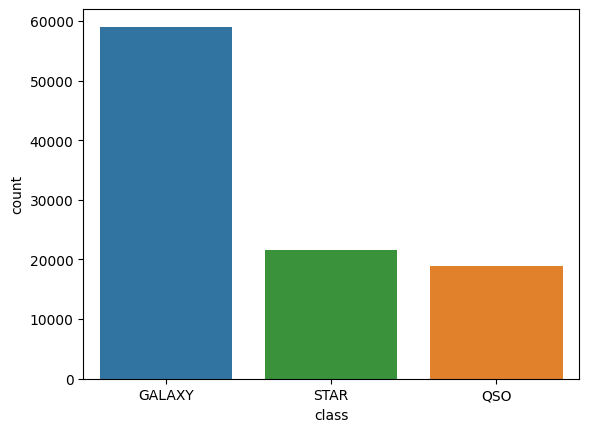

In [252]:
sns.countplot(data=df_copy, x='class', hue='class', legend=False, order=df['class'].value_counts().index)
plt.show()

Dataset bem desbalanceado com mais ocorrências de GALAXY em comparação as outras classes. Tratar isso mais a frente

## 1.2 - Features

In [294]:
df_copy["class"]=[0 if i == "GALAXY" else 1 if i == "STAR" else 2 for i in df_copy["class"]]
df_copy.corr()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
obj_ID,1.000000,-0.013580,-0.300852,0.015297,0.015687,0.153751,0.147480,0.013793,1.000000,NaN,-0.046618,0.031064,0.239805,0.000243,0.065929,0.239805,0.262982,0.066987
alpha,-0.013580,1.000000,0.138396,-0.001490,-0.002385,-0.021338,-0.022682,-0.002869,-0.013581,NaN,0.020010,-0.165403,-0.001628,0.004280,0.001373,-0.001629,0.020774,0.031090
delta,-0.300852,0.138396,1.000000,0.002102,0.003553,-0.006408,-0.003912,0.003671,-0.300854,NaN,0.032635,-0.173147,0.112832,0.056878,0.031798,0.112831,0.107692,0.028383
u,0.015297,-0.001490,0.002102,1.000000,0.999313,0.054034,0.045621,0.998100,0.015296,NaN,0.003569,-0.008421,0.029911,-0.017707,0.014344,0.029911,0.031915,0.016247
g,0.015687,-0.002385,0.003553,0.999313,1.000000,0.062251,0.056136,0.999164,0.015686,NaN,0.003528,-0.008905,0.039337,-0.005888,0.023019,0.039337,0.040167,0.017396
r,0.153751,-0.021338,-0.006408,0.054034,0.062251,1.000000,0.962887,0.053550,0.153749,NaN,0.008736,-0.027221,0.654947,0.151860,0.435545,0.654945,0.670961,0.222271
i,0.147480,-0.022682,-0.003912,0.045621,0.056136,0.962887,1.000000,0.055857,0.147478,NaN,0.007849,-0.027537,0.661426,0.286222,0.495096,0.661425,0.672381,0.213937
z,0.013793,-0.002869,0.003671,0.998100,0.999164,0.053550,0.055857,1.000000,0.013793,NaN,0.003384,-0.008965,0.037712,0.017421,0.030470,0.037712,0.037369,0.014600
run_ID,1.000000,-0.013581,-0.300854,0.015296,0.015686,0.153749,0.147478,0.013793,1.000000,NaN,-0.046719,0.031064,0.239804,0.000241,0.065929,0.239804,0.262982,0.066974
rerun_ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


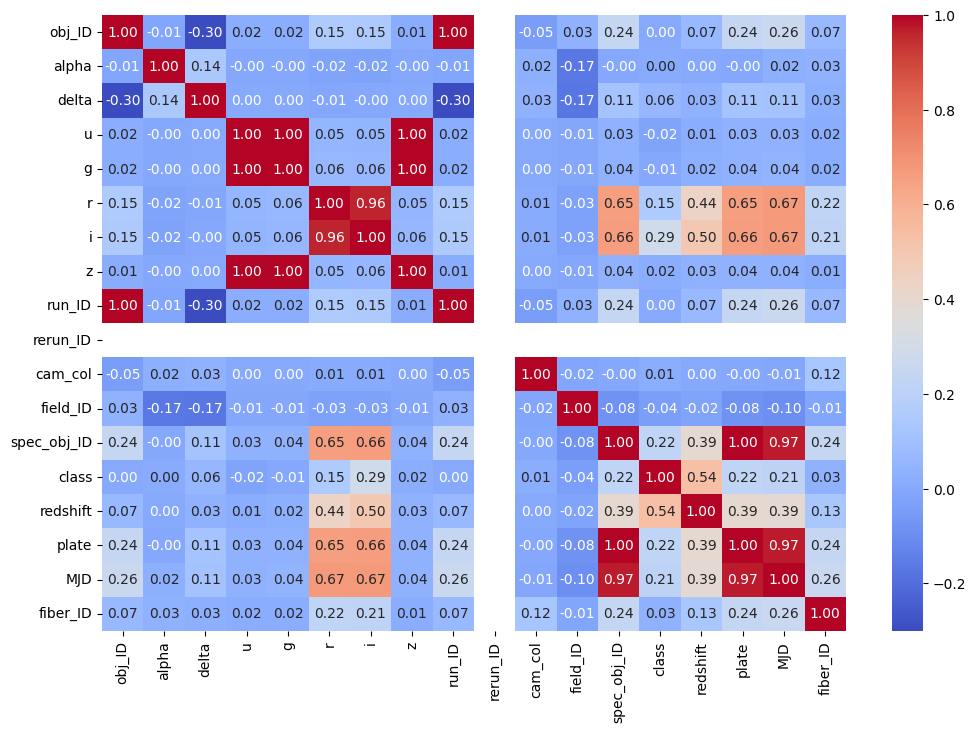

In [254]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_copy.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [295]:
df_copy = df_copy.drop(columns=['rerun_ID', 'obj_ID', 'alpha', 'delta', 'run_ID', 'cam_col','field_ID',
                               'spec_obj_ID', 'fiber_ID', 'plate', 'MJD'])

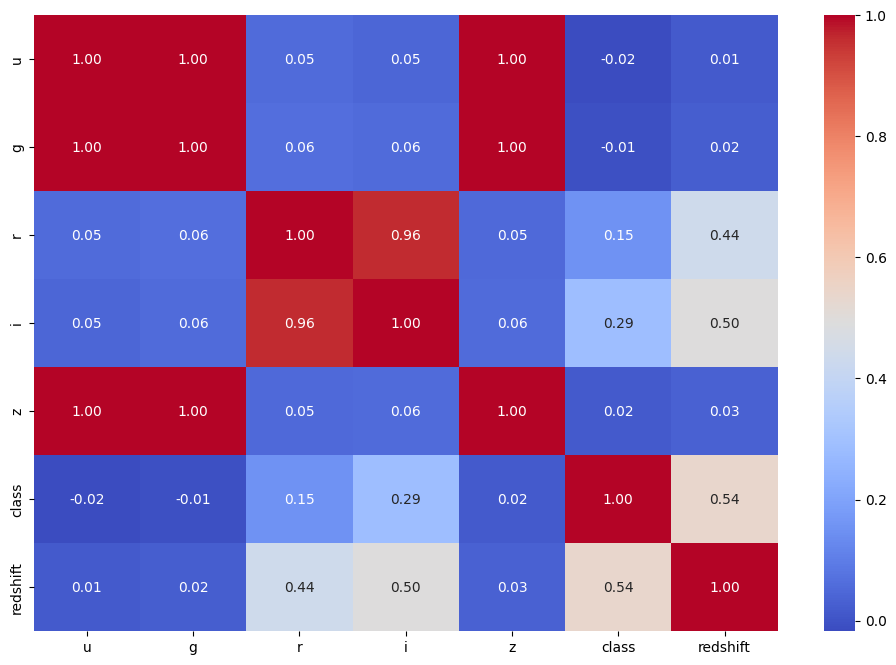

In [256]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_copy.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [257]:
df_copy.corr()['class']

u          -0.017707
g          -0.005888
r           0.151860
i           0.286222
z           0.017421
class       1.000000
redshift    0.535678
Name: class, dtype: float64

# 2 - Pré-processamento

In [296]:
X = df_copy.drop(columns=['class'])
y = df_copy['class']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

print(len(X_train), len(X_val), len(X_test))

67719 16930 14939


In [297]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train) 
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [298]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
weights = torch.tensor(weights, dtype=torch.float32)

print(weights)

tensor([0.5623, 1.5373, 1.7507])


In [299]:
class StarDataset(Dataset):
    def __init__(self, X, y):
        self.data = torch.tensor(X, dtype=torch.float32)
        self.label = torch.tensor(y.to_numpy(), dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (self.data[idx], self.label[idx])

In [300]:
train_dataset = StarDataset(X_train, y_train)
val_dataset = StarDataset(X_val, y_val)
test_dataset = StarDataset(X_test, y_test)

In [301]:
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=64)
val_dataloader = DataLoader(val_dataset, shuffle=False, batch_size=64)
test_dataloader = DataLoader(test_dataset, shuffle=False, batch_size=64)

In [264]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(6, 64)
        self.output = nn.Linear(64, 3)

    def forward(self, x):
        x = F.relu(self.hidden(x))
        return self.output(x)

In [265]:
model = Model()
loss_func = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 3 - Treinamento



## 3.1 - Modelo Base: 6 -> 64 -> 3

Arquitetura mínima com uma camada escondida de 64 neurônios. Serve como ponto de referência para todos os experimentos seguintes.
- Entrada: 6 features físicas (u, g, r, i, z, redshift)
- Saída: 3 classes (GALAXY=0, STAR=1, QSO=2)
- Otimizador: Adam com lr=1e-3
- Loss: CrossEntropyLoss com class weights para compensar o desbalanceamento

In [266]:
num_epochs = 50
train_losses = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_idx, (X_batch, y_batch) in enumerate(train_dataloader):
        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_func(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    val_correct = 0.0
    with torch.no_grad():
        for batch_idx, (X_batch, y_batch) in enumerate(val_dataloader):
            output = model(X_batch)
            val_loss += loss_func(output, y_batch).item()
            pred = torch.argmax(output, dim=1)
            val_correct += (pred == y_batch).sum().item()
            
            

    tl = train_loss / len(train_dataloader)
    vl = val_loss / len(val_dataloader)
    val_acc = val_correct / len(val_dataset)

    train_losses.append(tl)
    val_losses.append(vl)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | train: {tl:.4f} | val: {vl:.4f} | acc: {val_acc:.4f}")

Epoch 1 | train: 0.3899 | val: 0.2280 | acc: 0.9176
Epoch 2 | train: 0.2078 | val: 0.1827 | acc: 0.9350
Epoch 3 | train: 0.1704 | val: 0.1599 | acc: 0.9440
Epoch 4 | train: 0.1531 | val: 0.1468 | acc: 0.9468
Epoch 5 | train: 0.1412 | val: 0.1370 | acc: 0.9568
Epoch 6 | train: 0.1325 | val: 0.1298 | acc: 0.9505
Epoch 7 | train: 0.1252 | val: 0.1230 | acc: 0.9565
Epoch 8 | train: 0.1199 | val: 0.1199 | acc: 0.9569
Epoch 9 | train: 0.1153 | val: 0.1149 | acc: 0.9600
Epoch 10 | train: 0.1120 | val: 0.1136 | acc: 0.9563
Epoch 11 | train: 0.1090 | val: 0.1099 | acc: 0.9620
Epoch 12 | train: 0.1062 | val: 0.1134 | acc: 0.9649
Epoch 13 | train: 0.1042 | val: 0.1102 | acc: 0.9558
Epoch 14 | train: 0.1024 | val: 0.1038 | acc: 0.9642
Epoch 15 | train: 0.1007 | val: 0.1060 | acc: 0.9688
Epoch 16 | train: 0.0990 | val: 0.1022 | acc: 0.9686
Epoch 17 | train: 0.0982 | val: 0.1005 | acc: 0.9647
Epoch 18 | train: 0.0971 | val: 0.1000 | acc: 0.9655
Epoch 19 | train: 0.0956 | val: 0.0985 | acc: 0.9652
Ep

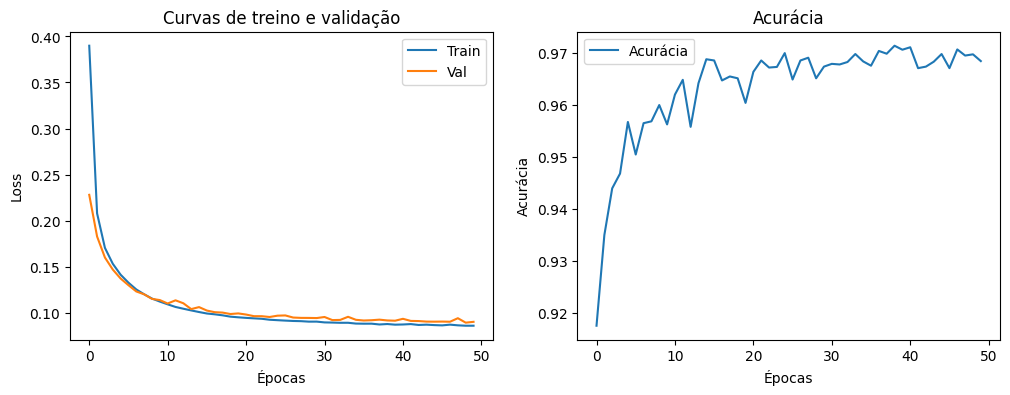

In [267]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(train_losses, label='Train') 
axs[0].plot(val_losses, label='Val')
axs[0].set_title('Curvas de treino e validação')
axs[0].set_xlabel('Épocas')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(val_accs, label='Acurácia')
axs[1].set_title('Acurácia')
axs[1].set_xlabel('Épocas')
axs[1].set_ylabel('Acurácia')
axs[1].legend()

plt.show()

Resultado:

As curvas de treino e validação convergem juntas em torno de loss ≈ 0.092** com acurácia ~97%
Não há sinal de overfitting, o modelo generaliza bem mesmo com arquitetura simples. O loss ainda estava caindo levemente na época 50, indicando que o modelo poderia melhorar com mais épocas.

# 4 - Variando Profundidade e Largura

Testando uma arquitetura mais profunda e larga: 6 -> 256 -> 128 -> 64 -> 3

In [268]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(6, 256)
        self.hidden2 = nn.Linear(256, 128)
        self.hidden3 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 3)

    def forward(self, x):
        x = F.relu(self.hidden(x))
        x = F.relu(self.hidden2(x))
        x = F.relu(self.hidden3(x))
        return self.output(x)

In [269]:
model = Model()
loss_func = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [270]:
num_epochs = 50
train_losses = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_idx, (X_batch, y_batch) in enumerate(train_dataloader):
        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_func(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    val_correct = 0.0
    with torch.no_grad():
        for batch_idx, (X_batch, y_batch) in enumerate(val_dataloader):
            output = model(X_batch)
            val_loss += loss_func(output, y_batch).item()
            pred = torch.argmax(output, dim=1)
            val_correct += (pred == y_batch).sum().item()
            
            

    tl = train_loss / len(train_dataloader)
    vl = val_loss / len(val_dataloader)
    val_acc = val_correct / len(val_dataset)

    train_losses.append(tl)
    val_losses.append(vl)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | train: {tl:.4f} | val: {vl:.4f} | acc: {val_acc:.4f}")

Epoch 1 | train: 0.2782 | val: 0.1307 | acc: 0.9546
Epoch 2 | train: 0.1125 | val: 0.1145 | acc: 0.9517
Epoch 3 | train: 0.1027 | val: 0.1117 | acc: 0.9610
Epoch 4 | train: 0.1002 | val: 0.0979 | acc: 0.9668
Epoch 5 | train: 0.0981 | val: 0.1017 | acc: 0.9646
Epoch 6 | train: 0.0968 | val: 0.0919 | acc: 0.9657
Epoch 7 | train: 0.1012 | val: 0.0949 | acc: 0.9627
Epoch 8 | train: 0.0935 | val: 0.0889 | acc: 0.9682
Epoch 9 | train: 0.0910 | val: 0.0948 | acc: 0.9629
Epoch 10 | train: 0.0910 | val: 0.0894 | acc: 0.9698
Epoch 11 | train: 0.0921 | val: 0.0896 | acc: 0.9713
Epoch 12 | train: 0.0928 | val: 0.1063 | acc: 0.9660
Epoch 13 | train: 0.0895 | val: 0.0863 | acc: 0.9726
Epoch 14 | train: 0.0867 | val: 0.0886 | acc: 0.9704
Epoch 15 | train: 0.0880 | val: 0.0886 | acc: 0.9682
Epoch 16 | train: 0.0873 | val: 0.0871 | acc: 0.9724
Epoch 17 | train: 0.0869 | val: 0.0944 | acc: 0.9721
Epoch 18 | train: 0.0874 | val: 0.0883 | acc: 0.9673
Epoch 19 | train: 0.0848 | val: 0.1051 | acc: 0.9490
Ep

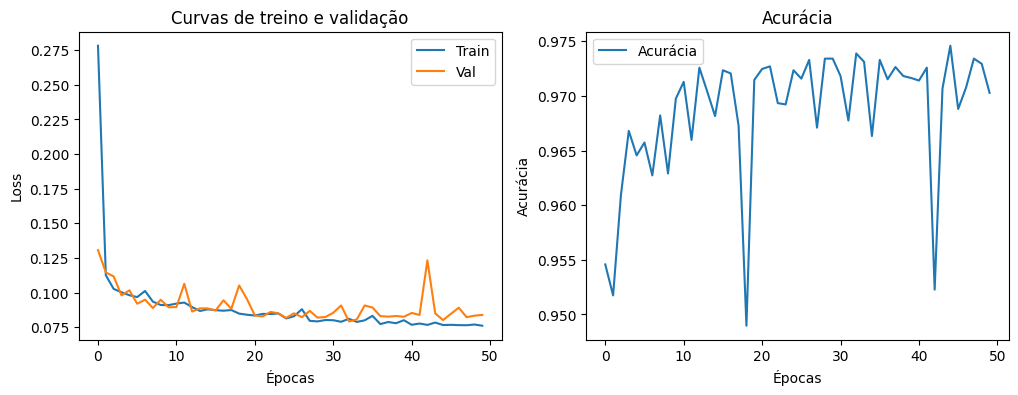

In [271]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(train_losses, label='Train') 
axs[0].plot(val_losses, label='Val')
axs[0].set_title('Curvas de treino e validação')
axs[0].set_xlabel('Épocas')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(val_accs, label='Acurácia')
axs[1].set_title('Acurácia')
axs[1].set_xlabel('Épocas')
axs[1].set_ylabel('Acurácia')
axs[1].legend()

plt.show()

Resultado:

| Modelo | Val Loss | Acurácia |
|---|---|---|
| Base (6 -> 64 -> 3) | ~0.092 | ~97.0% |
| Profundo+Largo (6 -> 256 -> 128 -> 64 -> 3) | ~0.081 | ~97.35% |

O modelo maior apresentou leve melhora no val loss, porém com maior instabilidade com picos visíveis nas curvas de validação.
Mais parâmetros aumentam a capacidade do modelo mas também a sensibilidade ao ruído dos batches. Esse modelo vai ser usado para testar otimizações e regularizações

# 5 - Variando Learning Rating e Épocas


Usando a arquitetura base (6 -> 64 -> 3) e variando um hiperparâmetro por vez para isolar seus efeitos

In [272]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(6, 64)
        self.output = nn.Linear(64, 3)

    def forward(self, x):
        x = F.relu(self.hidden(x))
        return self.output(x)

## 5.1 LR = 1e-1

In [273]:
model = Model()
loss_func = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-1)

In [274]:
num_epochs = 50
train_losses = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_idx, (X_batch, y_batch) in enumerate(train_dataloader):
        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_func(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    val_correct = 0.0
    with torch.no_grad():
        for batch_idx, (X_batch, y_batch) in enumerate(val_dataloader):
            output = model(X_batch)
            val_loss += loss_func(output, y_batch).item()
            pred = torch.argmax(output, dim=1)
            val_correct += (pred == y_batch).sum().item()
            
            

    tl = train_loss / len(train_dataloader)
    vl = val_loss / len(val_dataloader)
    val_acc = val_correct / len(val_dataset)

    train_losses.append(tl)
    val_losses.append(vl)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | train: {tl:.4f} | val: {vl:.4f} | acc: {val_acc:.4f}")

Epoch 1 | train: 0.3952 | val: 0.1204 | acc: 0.9646
Epoch 2 | train: 0.1420 | val: 0.1441 | acc: 0.9357
Epoch 3 | train: 0.1430 | val: 0.1102 | acc: 0.9671
Epoch 4 | train: 0.1334 | val: 0.1183 | acc: 0.9676
Epoch 5 | train: 0.1335 | val: 0.1163 | acc: 0.9702
Epoch 6 | train: 0.1393 | val: 0.1248 | acc: 0.9409
Epoch 7 | train: 0.1234 | val: 0.2096 | acc: 0.9514
Epoch 8 | train: 0.2406 | val: 0.2237 | acc: 0.9289
Epoch 9 | train: 0.1343 | val: 0.1314 | acc: 0.9497
Epoch 10 | train: 0.1276 | val: 0.1351 | acc: 0.9540
Epoch 11 | train: 0.1273 | val: 0.1428 | acc: 0.9198
Epoch 12 | train: 0.1240 | val: 0.1261 | acc: 0.9425
Epoch 13 | train: 0.1251 | val: 0.1218 | acc: 0.9636
Epoch 14 | train: 0.1193 | val: 0.1245 | acc: 0.9631
Epoch 15 | train: 0.1232 | val: 0.1276 | acc: 0.9650
Epoch 16 | train: 0.1209 | val: 0.1318 | acc: 0.9641
Epoch 17 | train: 0.1196 | val: 0.1079 | acc: 0.9639
Epoch 18 | train: 0.1147 | val: 0.1086 | acc: 0.9697
Epoch 19 | train: 0.1242 | val: 0.1091 | acc: 0.9667
Ep

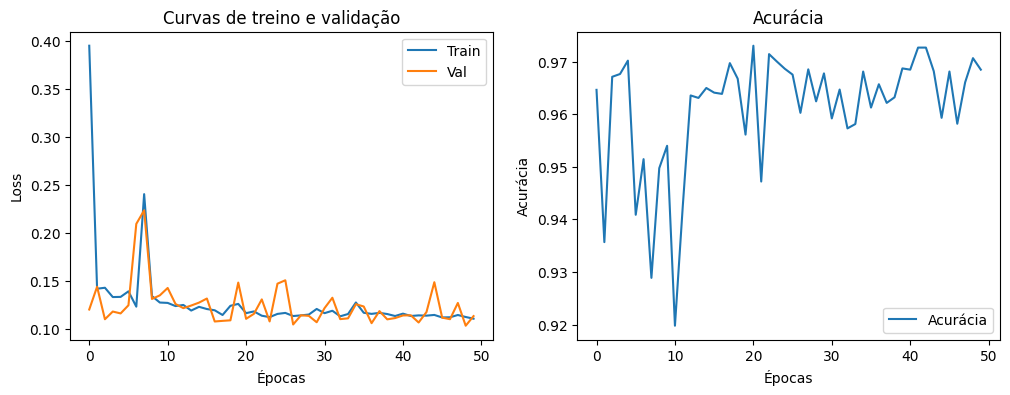

In [275]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(train_losses, label='Train') 
axs[0].plot(val_losses, label='Val')
axs[0].set_title('Curvas de treino e validação')
axs[0].set_xlabel('Épocas')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(val_accs, label='Acurácia')
axs[1].set_title('Acurácia')
axs[1].set_xlabel('Épocas')
axs[1].set_ylabel('Acurácia')
axs[1].legend()

plt.show()

Loss de treino e validação oscilando sem convergir, picos extremos na validação (val loss chegou a 0.27) . O gradiente dá passos grandes demais e pula o mínimo repetidamente.

## 5.2 - LR = 1e-2

In [276]:
model = Model()
loss_func = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-2)

In [277]:
num_epochs = 50
train_losses = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_idx, (X_batch, y_batch) in enumerate(train_dataloader):
        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_func(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    val_correct = 0.0
    with torch.no_grad():
        for batch_idx, (X_batch, y_batch) in enumerate(val_dataloader):
            output = model(X_batch)
            val_loss += loss_func(output, y_batch).item()
            pred = torch.argmax(output, dim=1)
            val_correct += (pred == y_batch).sum().item()
            
            

    tl = train_loss / len(train_dataloader)
    vl = val_loss / len(val_dataloader)
    val_acc = val_correct / len(val_dataset)

    train_losses.append(tl)
    val_losses.append(vl)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | train: {tl:.4f} | val: {vl:.4f} | acc: {val_acc:.4f}")

Epoch 1 | train: 0.4048 | val: 0.1242 | acc: 0.9649
Epoch 2 | train: 0.1259 | val: 0.1072 | acc: 0.9644
Epoch 3 | train: 0.1101 | val: 0.1088 | acc: 0.9578
Epoch 4 | train: 0.1078 | val: 0.1114 | acc: 0.9707
Epoch 5 | train: 0.1039 | val: 0.1012 | acc: 0.9702
Epoch 6 | train: 0.1056 | val: 0.0994 | acc: 0.9601
Epoch 7 | train: 0.1023 | val: 0.1173 | acc: 0.9640
Epoch 8 | train: 0.1007 | val: 0.0934 | acc: 0.9697
Epoch 9 | train: 0.1020 | val: 0.1019 | acc: 0.9644
Epoch 10 | train: 0.1000 | val: 0.1104 | acc: 0.9588
Epoch 11 | train: 0.0991 | val: 0.0948 | acc: 0.9663
Epoch 12 | train: 0.0986 | val: 0.0959 | acc: 0.9672
Epoch 13 | train: 0.0971 | val: 0.0940 | acc: 0.9666
Epoch 14 | train: 0.0947 | val: 0.1091 | acc: 0.9516
Epoch 15 | train: 0.1024 | val: 0.0993 | acc: 0.9719
Epoch 16 | train: 0.0985 | val: 0.0938 | acc: 0.9695
Epoch 17 | train: 0.0954 | val: 0.0968 | acc: 0.9668
Epoch 18 | train: 0.0966 | val: 0.0897 | acc: 0.9685
Epoch 19 | train: 0.0952 | val: 0.0978 | acc: 0.9701
Ep

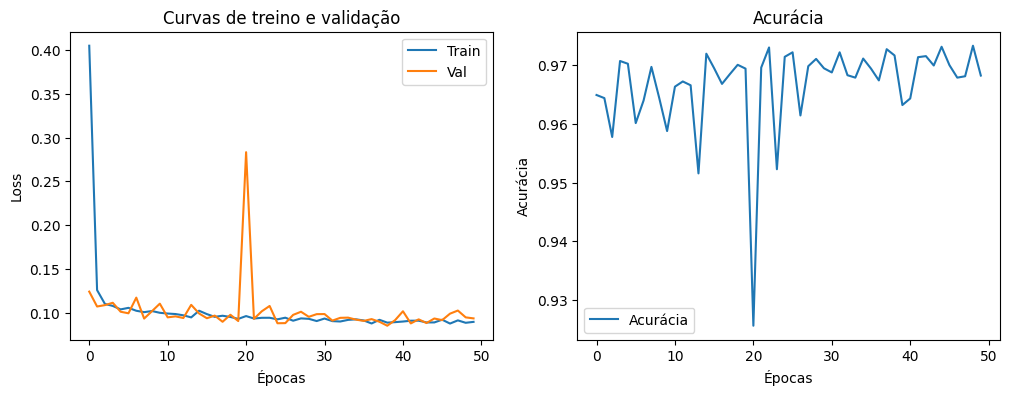

In [278]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(train_losses, label='Train') 
axs[0].plot(val_losses, label='Val')
axs[0].set_title('Curvas de treino e validação')
axs[0].set_xlabel('Épocas')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(val_accs, label='Acurácia')
axs[1].set_title('Acurácia')
axs[1].set_xlabel('Épocas')
axs[1].set_ylabel('Acurácia')
axs[1].legend()

plt.show()

Convergência mais rápida que o padrão, com alguma oscilação controlada
Val loss final  de aproximadamente de 0.089 com acurácia aproximada de 97.3%

## 5.3 - LR = 1e-4

In [279]:
model = Model()
loss_func = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 50
train_losses = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_idx, (X_batch, y_batch) in enumerate(train_dataloader):
        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_func(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    val_correct = 0.0
    with torch.no_grad():
        for batch_idx, (X_batch, y_batch) in enumerate(val_dataloader):
            output = model(X_batch)
            val_loss += loss_func(output, y_batch).item()
            pred = torch.argmax(output, dim=1)
            val_correct += (pred == y_batch).sum().item()
            
            

    tl = train_loss / len(train_dataloader)
    vl = val_loss / len(val_dataloader)
    val_acc = val_correct / len(val_dataset)

    train_losses.append(tl)
    val_losses.append(vl)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | train: {tl:.4f} | val: {vl:.4f} | acc: {val_acc:.4f}")
    

Epoch 1 | train: 0.8525 | val: 0.6579 | acc: 0.6043
Epoch 2 | train: 0.5606 | val: 0.4795 | acc: 0.7869
Epoch 3 | train: 0.4277 | val: 0.3818 | acc: 0.8371
Epoch 4 | train: 0.3490 | val: 0.3201 | acc: 0.8864
Epoch 5 | train: 0.3020 | val: 0.2856 | acc: 0.8891
Epoch 6 | train: 0.2746 | val: 0.2634 | acc: 0.9006
Epoch 7 | train: 0.2556 | val: 0.2476 | acc: 0.9086
Epoch 8 | train: 0.2418 | val: 0.2351 | acc: 0.9127
Epoch 9 | train: 0.2305 | val: 0.2249 | acc: 0.9154
Epoch 10 | train: 0.2212 | val: 0.2162 | acc: 0.9175
Epoch 11 | train: 0.2132 | val: 0.2086 | acc: 0.9194
Epoch 12 | train: 0.2066 | val: 0.2024 | acc: 0.9242
Epoch 13 | train: 0.2001 | val: 0.1976 | acc: 0.9253
Epoch 14 | train: 0.1956 | val: 0.1933 | acc: 0.9232
Epoch 15 | train: 0.1911 | val: 0.1891 | acc: 0.9310
Epoch 16 | train: 0.1874 | val: 0.1852 | acc: 0.9321
Epoch 17 | train: 0.1835 | val: 0.1819 | acc: 0.9334
Epoch 18 | train: 0.1800 | val: 0.1786 | acc: 0.9340
Epoch 19 | train: 0.1768 | val: 0.1756 | acc: 0.9360
Ep

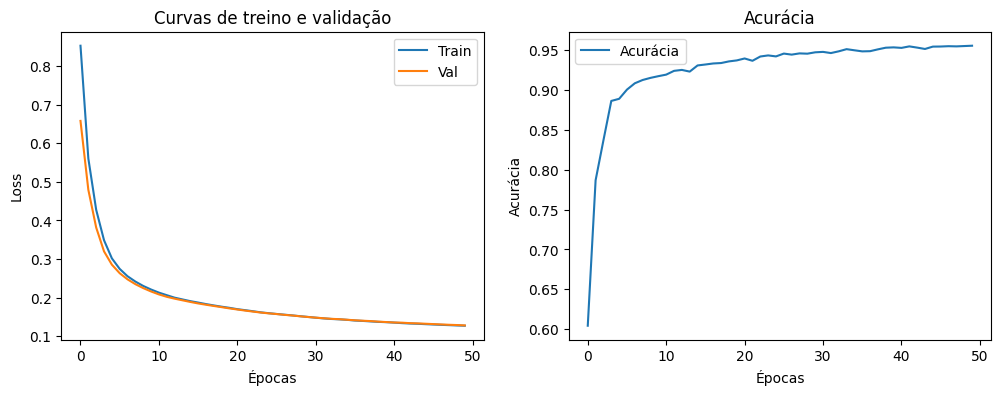

In [280]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(train_losses, label='Train') 
axs[0].plot(val_losses, label='Val')
axs[0].set_title('Curvas de treino e validação')
axs[0].set_xlabel('Épocas')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(val_accs, label='Acurácia')
axs[1].set_title('Acurácia')
axs[1].set_xlabel('Épocas')
axs[1].set_ylabel('Acurácia')
axs[1].legend()

plt.show()

Loss ainda em 0.127 na época 50. O modelo não convergiu dentro de 50 épocas. Acurácia de apenas 95.7% contra 97% do 1e-3.
Passos de gradiente muito pequenos: o modelo aprende, mas lentamente demais.
Sinal clássico de underfitting por learning rate baixo

# 6 - Variando Épocas

Fixando o LR em 1e-3 e testando 10, 50 e 200 épocas.

## 6.1 - 10 Épocas

In [281]:
model = Model()
loss_func = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [282]:
num_epochs = 10
train_losses = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_idx, (X_batch, y_batch) in enumerate(train_dataloader):
        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_func(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    val_correct = 0.0
    with torch.no_grad():
        for batch_idx, (X_batch, y_batch) in enumerate(val_dataloader):
            output = model(X_batch)
            val_loss += loss_func(output, y_batch).item()
            pred = torch.argmax(output, dim=1)
            val_correct += (pred == y_batch).sum().item()
            
            

    tl = train_loss / len(train_dataloader)
    vl = val_loss / len(val_dataloader)
    val_acc = val_correct / len(val_dataset)

    train_losses.append(tl)
    val_losses.append(vl)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | train: {tl:.4f} | val: {vl:.4f} | acc: {val_acc:.4f}")
    

Epoch 1 | train: 0.3783 | val: 0.2132 | acc: 0.9133
Epoch 2 | train: 0.1998 | val: 0.1755 | acc: 0.9351
Epoch 3 | train: 0.1637 | val: 0.1538 | acc: 0.9457
Epoch 4 | train: 0.1496 | val: 0.1405 | acc: 0.9521
Epoch 5 | train: 0.1367 | val: 0.1330 | acc: 0.9536
Epoch 6 | train: 0.1296 | val: 0.1266 | acc: 0.9562
Epoch 7 | train: 0.1240 | val: 0.1216 | acc: 0.9592
Epoch 8 | train: 0.1189 | val: 0.1181 | acc: 0.9588
Epoch 9 | train: 0.1154 | val: 0.1155 | acc: 0.9546
Epoch 10 | train: 0.1115 | val: 0.1126 | acc: 0.9568


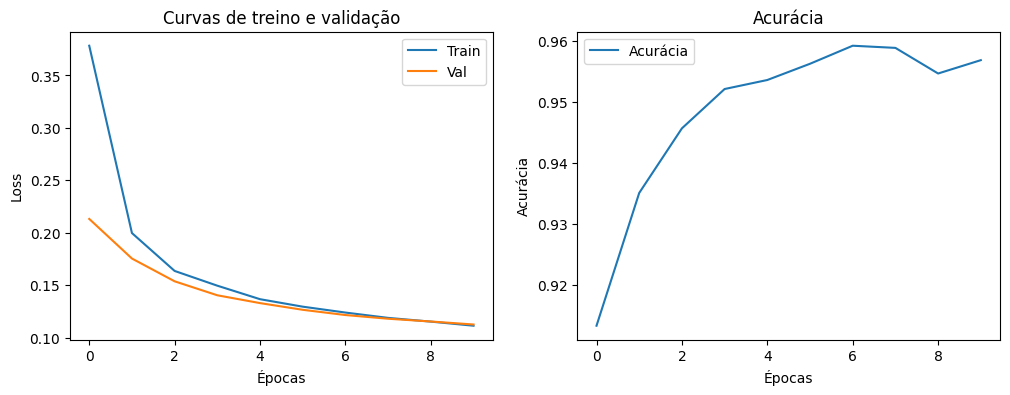

In [283]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(train_losses, label='Train') 
axs[0].plot(val_losses, label='Val')
axs[0].set_title('Curvas de treino e validação')
axs[0].set_xlabel('Épocas')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(val_accs, label='Acurácia')
axs[1].set_title('Acurácia')
axs[1].set_xlabel('Épocas')
axs[1].set_ylabel('Acurácia')
axs[1].legend()

plt.show()

Val loss de 0.1126 e acurácia de 95.7%, bem abaixo do modelo com 50 épocas.
O modelo foi interrompido cedo demais, ainda havia muito a aprender.

## 6.2 - 200 Épocas

In [284]:
num_epochs = 200
train_losses = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_idx, (X_batch, y_batch) in enumerate(train_dataloader):
        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_func(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    val_correct = 0.0
    with torch.no_grad():
        for batch_idx, (X_batch, y_batch) in enumerate(val_dataloader):
            output = model(X_batch)
            val_loss += loss_func(output, y_batch).item()
            pred = torch.argmax(output, dim=1)
            val_correct += (pred == y_batch).sum().item()
            
            

    tl = train_loss / len(train_dataloader)
    vl = val_loss / len(val_dataloader)
    val_acc = val_correct / len(val_dataset)

    train_losses.append(tl)
    val_losses.append(vl)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | train: {tl:.4f} | val: {vl:.4f} | acc: {val_acc:.4f}")
    

Epoch 1 | train: 0.1092 | val: 0.1101 | acc: 0.9593
Epoch 2 | train: 0.1064 | val: 0.1079 | acc: 0.9591
Epoch 3 | train: 0.1051 | val: 0.1074 | acc: 0.9620
Epoch 4 | train: 0.1026 | val: 0.1046 | acc: 0.9626
Epoch 5 | train: 0.1014 | val: 0.1069 | acc: 0.9614
Epoch 6 | train: 0.1000 | val: 0.1023 | acc: 0.9677
Epoch 7 | train: 0.0988 | val: 0.1016 | acc: 0.9670
Epoch 8 | train: 0.0977 | val: 0.1006 | acc: 0.9639
Epoch 9 | train: 0.0966 | val: 0.1001 | acc: 0.9670
Epoch 10 | train: 0.0956 | val: 0.0987 | acc: 0.9662
Epoch 11 | train: 0.0952 | val: 0.0984 | acc: 0.9686
Epoch 12 | train: 0.0944 | val: 0.0977 | acc: 0.9684
Epoch 13 | train: 0.0941 | val: 0.0958 | acc: 0.9670
Epoch 14 | train: 0.0936 | val: 0.0952 | acc: 0.9680
Epoch 15 | train: 0.0929 | val: 0.0959 | acc: 0.9652
Epoch 16 | train: 0.0921 | val: 0.0967 | acc: 0.9703
Epoch 17 | train: 0.0922 | val: 0.0943 | acc: 0.9677
Epoch 18 | train: 0.0918 | val: 0.0978 | acc: 0.9625
Epoch 19 | train: 0.0911 | val: 0.0947 | acc: 0.9643
Ep

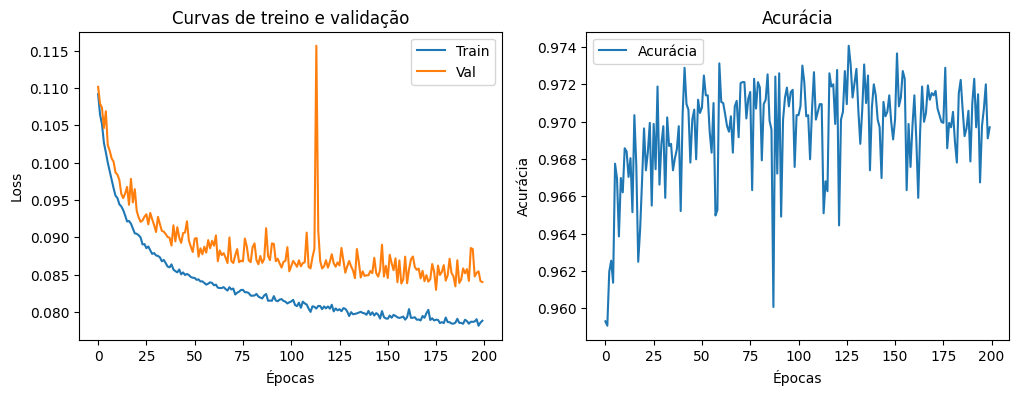

In [285]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(train_losses, label='Train') 
axs[0].plot(val_losses, label='Val')
axs[0].set_title('Curvas de treino e validação')
axs[0].set_xlabel('Épocas')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(val_accs, label='Acurácia')
axs[1].set_title('Acurácia')
axs[1].set_xlabel('Épocas')
axs[1].set_ylabel('Acurácia')
axs[1].legend()

plt.show()

Val loss de 0.0840 e acurácia de 96.97% com uma leve melhora em relação as 50 épocas.
O modelo não overfitou mesmo com 200 épocas
Para induzir overfitting talvez seria necessário um modelo maior sem regularização.

| Épocas | Val Loss | Acurácia |
|---|---|---|
| 10 | 0.1126 | 95.7% |
| 50 | ~0.092 | ~97.0% |
| 200 | 0.0840 | 96.97% |

# 7 - Regularização e Otimizadores

Usando o modelo mais profundo (6 -> 256 -> 128 -> 64 -> 3) com Dropout (p=0.3) entre as camadas. O Dropout desativa neurônios aleatoriamente durante o treino, forçando a rede a aprender representações independentes e reduzindo o overfitting.

Usando três otimizadores diferentes:
- Adam — referência, adaptativo
- AdamW — Adam com weight decay (L2) corrigido
- SGD — gradiente descendente com momentum

In [306]:
class ModelDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(6, 256)
        self.hidden2 = nn.Linear(256, 128)
        self.hidden3 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 3)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.dropout(F.relu(self.hidden1(x)))
        x = self.dropout(F.relu(self.hidden2(x)))
        x = self.dropout(F.relu(self.hidden3(x)))
        return self.output(x)

In [307]:
results = {}

otimizadores = {
      'Adam':  lambda params: optim.Adam(params, lr=1e-3),
      'AdamW': lambda params: optim.AdamW(params, lr=1e-3, weight_decay=1e-4),
      'SGD':   lambda params: optim.SGD(params, lr=1e-3, momentum=0.9),
}

for nome, opt_fn in otimizadores.items():
    torch.manual_seed(42)
    model = ModelDropout()
    loss_func = nn.CrossEntropyLoss(weight=weights)
    optimizer = opt_fn(model.parameters())
    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(50):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_dataloader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = loss_func(output, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss, val_correct = 0.0, 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_dataloader:
                output = model(X_batch)
                val_loss += loss_func(output, y_batch).item()
                val_correct += (torch.argmax(output, dim=1) == y_batch).sum().item()

        tl = train_loss / len(train_dataloader)
        vl = val_loss / len(val_dataloader)
        va = val_correct / len(val_dataset)
        train_losses.append(tl)
        val_losses.append(vl)
        val_accs.append(va)

    results[nome] = {'train': train_losses, 'val': val_losses, 'acc': val_accs}
    print(f"{nome} | val loss: {vl:.4f} | acc: {va:.4f}")

Adam | val loss: 0.0944 | acc: 0.9638
AdamW | val loss: 0.0867 | acc: 0.9694
SGD | val loss: 0.0977 | acc: 0.9663


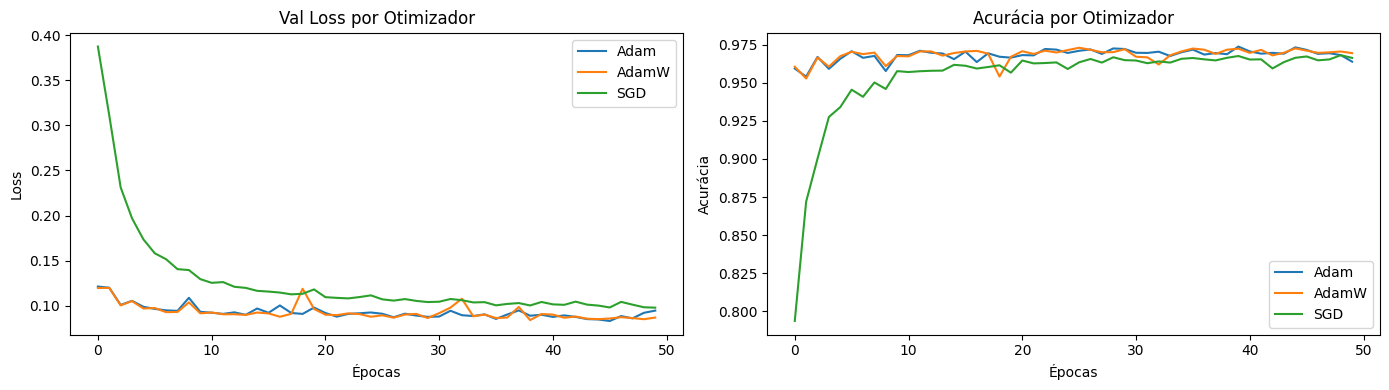

In [308]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

for nome, res in results.items():
    axs[0].plot(res['val'], label=nome)
    axs[1].plot(res['acc'], label=nome)

axs[0].set_title('Val Loss por Otimizador')
axs[0].set_xlabel('Épocas')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].set_title('Acurácia por Otimizador')
axs[1].set_xlabel('Épocas')
axs[1].set_ylabel('Acurácia')
axs[1].legend()

plt.tight_layout()
plt.show()

Resultado:

| Otimizador | Val Loss | Acurácia |
|---|---|---|
| Adam | 0.0944 | 96.38% |
| AdamW | 0.0867 | 96.94% |
| SGD | 0.0977 | 96.63% |

- AdamW foi o melhor, o weight decay penaliza pesos grandes, agindo como regularização adicional ao Dropout
- SGD convergiu muito mais devagar (loss iniciando em 0.40), mas chegou a resultado similar no final
- O Dropout estabilizou as curvas do modelo mais profundo, eliminando os picos de instabilidade observados

# 8 - Avaliação final no conjunto de teste


Modelo final: ModelDropout (6 -> 256 -> 128 -> 64 -> 3) com AdamW (lr=1e-3, weight_decay=1e-4).

              precision    recall  f1-score   support

      GALAXY       0.98      0.97      0.98      8856
        STAR       0.98      1.00      0.99      3239
         QSO       0.93      0.95      0.94      2844

    accuracy                           0.97     14939
   macro avg       0.96      0.97      0.97     14939
weighted avg       0.97      0.97      0.97     14939



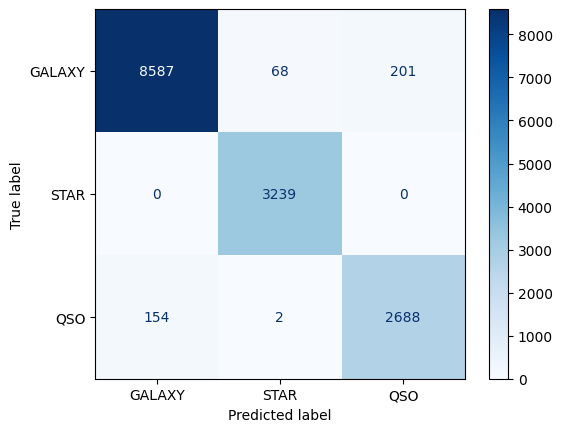

In [309]:
# Treino final
torch.manual_seed(42)
model_final = ModelDropout()
loss_func = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.AdamW(model_final.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(50):
    model_final.train()
    for X_batch, y_batch in train_dataloader:
        optimizer.zero_grad()
        output = model_final(X_batch)
        loss = loss_func(output, y_batch)
        loss.backward()
        optimizer.step()

# Avaliação no teste
model_final.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_dataloader:
        output = model_final(X_batch)
        preds = torch.argmax(output, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(all_labels, all_preds, target_names=['GALAXY', 'STAR', 'QSO']))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['GALAXY', 'STAR', 'QSO'])
disp.plot(cmap='Blues')
plt.show()

### Conclusão

O modelo final atingiu 97% de acurácia no conjunto de teste nunca visto durante o treinamento.

### Métricas por classe

| Classe | Precision | Recall | F1-Score | Suporte |
|---|---|---|---|---|
| GALAXY | 0.98 | 0.97 | 0.98 | 8856 |
| STAR | 0.98 | 1.00 | 0.99 | 3239 |
| QSO | 0.93 | 0.95 | 0.94 | 2844 |
| Média | 0.96 | 0.97 | 0.97 | 14939 |

### Análise da Matriz de Confusão

- STAR — classificação perfeita: 3239/3239 acertos, zero erros.
- GALAXY — 8587 acertos, 201 confundidos com QSO.
- QSO — classe mais difícil: 154 confundidos com GALAXY. De acordo com o Gemini IA, quasares são núcleos galácticos ativos e fisicamente relacionados a galáxias, o que talvez explicaria a maior taxa de confusão.

### Sumário dos Experimentos

| Experimento | Melhor Config | Val Loss | Acurácia |
|---|---|---|---|
| Modelo base | 6 -> 64 -> 3 | ~0.092 | ~97.0% |
| Profundidade/Largura | 6 -> 256 -> 128 ->64 -> 3 | ~0.081 | ~97.35% |
| Learning Rate | 1e-3 | ~0.092 | ~97.0% |
| Épocas | 200 épocas | 0.084 | 96.97% |
| Regularização + Otimizador | Dropout + AdamW | 0.087 | 96.94% |

O modelo final combina a arquitetura mais profunda com Dropout e AdamW, equilibrando capacidade e regularização para obter o melhor resultado no teste.